# Banglore House Prices Prediction Model

## 1. Imports and Data Load

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, ShuffleSplit, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import pickle, json
import plotly.io as pio

pio.renderers.default = 'iframe'

In [ ]:
df = pd.read_csv('/kaggle/input/datasets/sumanbera19/bengaluru-house-price-dataset/bengaluru_house_prices.csv')
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [3]:
df.shape

(13320, 9)

## 2. Interactive Real Estate Analytics
This section performs EDA on the raw dataset using interactive visual analytics and statistical testing.
It covers: data distribution, composition, relationship, comparison, and univariate/bivariate/multivariate analysis.

In [ ]:
#Helper cell
import warnings
warnings.filterwarnings('ignore')

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from IPython.display import display, Markdown

eda_df = df.copy()
eda_df['location'] = eda_df['location'].astype(str).str.strip()

# Professional, real-estate-centric palette
real_estate_palette = [
    '#0B3C5D',  # deep slate blue
    '#328CC1',  # steel blue
    '#D9B310',  # ochre
    '#1D2731',  # charcoal
    '#6C7A89',  # cool gray
    '#B8A47E',  # sandstone
    '#3F681C',  # olive green
    '#A23E48'   # muted brick'
]

px.defaults.template = 'plotly_white'
px.defaults.color_discrete_sequence = real_estate_palette

def add_plot_interpretation(text):
    display(Markdown('**Interpretation & Key Findings**'))
    display(Markdown(text))

In [5]:
# Prepare analytics-ready numeric features without altering original df
eda_df['price'] = pd.to_numeric(eda_df['price'], errors='coerce')
eda_df['bath'] = pd.to_numeric(eda_df['bath'], errors='coerce')
eda_df['balcony'] = pd.to_numeric(eda_df['balcony'], errors='coerce')

eda_df['BHK'] = eda_df['size'].astype(str).str.extract(r'(\d+)')[0]
eda_df['BHK'] = pd.to_numeric(eda_df['BHK'], errors='coerce')

def sqft_to_num_eda(x):
    x = str(x)
    tokens = x.split('-')
    if len(tokens) == 2:
        try:
            return (float(tokens[0]) + float(tokens[1])) / 2
        except:
            return np.nan
    try:
        return float(x)
    except:
        return np.nan

eda_df['total_sqft_num'] = eda_df['total_sqft'].apply(sqft_to_num_eda)
eda_df['price_per_sqft'] = (eda_df['price'] * 100000) / eda_df['total_sqft_num']

num_cols = ['price', 'bath', 'balcony', 'BHK', 'total_sqft_num', 'price_per_sqft']
eda_num = eda_df[num_cols].copy()

display(eda_df.head(3))
display(eda_num.describe().T.round(2))

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,BHK,total_sqft_num,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07,2.0,1056.0,3699.810606
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00,4.0,2600.0,4615.384615
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00,3.0,1440.0,4305.555556


,count,mean,std,min,25%,50%,75%,max
price,13320.0,112.57,148.97,8.00,50.00,72.00,120.00,3600.0
bath,13247.0,2.69,1.34,1.00,2.00,2.00,3.00,40.0
balcony,12711.0,1.58,0.82,0.00,1.00,2.00,2.00,3.0
BHK,13304.0,2.80,1.29,1.00,2.00,3.00,3.00,43.0
total_sqft_num,13274.0,1559.63,1238.41,1.00,1100.00,1276.00,1680.00,52272.0
price_per_sqft,13274.0,7907.50,106429.59,267.83,4266.86,5434.31,7311.75,12000000.0


### 2.1 Data Distribution

#### 2.1.1 Price

In [6]:
fig = px.histogram(
    eda_df.dropna(subset=['price']),
    x='price',
    nbins=60,
    marginal='box',
    title='Price Distribution with Box Marginal (Raw Data)',
    labels={'price': 'Price (Lakhs)'}
)
fig.update_layout(height=520)
fig.show()

p_q1, p_q2, p_q3 = eda_df['price'].quantile([0.25, 0.50, 0.75]).values
add_plot_interpretation(
    f'- The price distribution is right-skewed with a long high-value tail.\n'
    f'- Median price is approximately **{p_q2:.2f} Lakhs**; interquartile range is **{p_q1:.2f} to {p_q3:.2f} Lakhs**.\n'
    f'- Outliers are visible at the upper end, indicating premium segments that should be modeled carefully.'
)

**Interpretation & Key Findings**

- The price distribution is right-skewed with a long high-value tail.
- Median price is approximately **72.00 Lakhs**; interquartile range is **50.00 to 120.00 Lakhs**.
- Outliers are visible at the upper end, indicating premium segments that should be modeled carefully.

#### 2.1.2 Price and BHK

In [7]:
fig = px.violin(
    eda_df.dropna(subset=['BHK', 'price']),
    x='BHK',
    y='price',
    box=True,
    points='suspectedoutliers',
    title='Price Distribution Across BHK Segments',
    labels={'BHK': 'Bedroom Count', 'price': 'Price (Lakhs)'}
)
fig.update_layout(height=520)
fig.show()

median_by_bhk = eda_df.groupby('BHK', dropna=True)['price'].median().sort_index()
add_plot_interpretation(
    '- Higher BHK segments generally shift to higher price bands, validating expected residential pricing behavior.\n'
    '- Distribution overlaps between adjacent BHK classes indicate neighborhood and property-quality effects.\n'
    f'- Median prices by BHK (sample): **{median_by_bhk.head(6).round(2).to_dict()}**.'
)

**Interpretation & Key Findings**

- Higher BHK segments generally shift to higher price bands, validating expected residential pricing behavior.
- Distribution overlaps between adjacent BHK classes indicate neighborhood and property-quality effects.
- Median prices by BHK (sample): **{1.0: 34.28, 2.0: 53.56, 3.0: 88.2, 4.0: 204.0, 5.0: 180.0, 6.0: 160.0}**.

### 2.2 Data Composition

#### 2.2.1 Area Types

In [9]:
area_comp = eda_df['area_type'].value_counts(dropna=False).reset_index()
area_comp.columns = ['area_type', 'count']
area_comp['share_pct'] = (area_comp['count'] / area_comp['count'].sum() * 100).round(2)

fig = px.pie(
    area_comp,
    names='area_type',
    values='count',
    hole=0.48,
    title='Dataset Composition by Area Type'
)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(height=520)
fig.show()

top_area = area_comp.iloc[0]
add_plot_interpretation(
    f'- The largest segment is **{top_area["area_type"]}** with **{top_area["share_pct"]}%** dataset share.\n'
    '- Composition concentration implies model predictions may be strongest for dominant inventory types.\n'
    '- Minority classes should be monitored for representation and model bias risk.'
)

**Interpretation & Key Findings**

- The largest segment is **Super built-up  Area** with **65.99%** dataset share.
- Composition concentration implies model predictions may be strongest for dominant inventory types.
- Minority classes should be monitored for representation and model bias risk.

#### 2.2.2 Top 15 Locations

In [10]:
top_locations = eda_df['location'].value_counts().head(15).reset_index()
top_locations.columns = ['location', 'count']

fig = px.treemap(
    top_locations,
    path=['location'],
    values='count',
    color='count',
    color_continuous_scale=['#DCEAF7', '#328CC1', '#0B3C5D'],
    title='Top 15 Locations by Listing Volume (Composition)'
)
fig.update_layout(height=560)
fig.show()

add_plot_interpretation(
    '- Listing supply is concentrated in a relatively small set of high-volume locations.\n'
    '- High concentration zones are suitable for baseline market trend tracking and robust statistical benchmarks.\n'
    '- Low-volume areas can be grouped for stable modeling and cleaner dashboard storytelling.'
)

**Interpretation & Key Findings**

- Listing supply is concentrated in a relatively small set of high-volume locations.
- High concentration zones are suitable for baseline market trend tracking and robust statistical benchmarks.
- Low-volume areas can be grouped for stable modeling and cleaner dashboard storytelling.

### 2.3 Data Relationship

#### 2.3.1 Price, BHK, Sqft & Size

In [11]:
plot_df = eda_df.dropna(subset=['total_sqft_num', 'price', 'BHK', 'area_type']).copy()
plot_df = plot_df[plot_df['total_sqft_num'] < plot_df['total_sqft_num'].quantile(0.99)]

fig = px.scatter(
    plot_df,
    x='total_sqft_num',
    y='price',
    color='area_type',
    size='BHK',
    hover_data=['location', 'bath', 'balcony'],
    trendline='ols',
    title='Relationship: Total Sqft vs Price (Colored by Area Type, Sized by BHK)',
    labels={'total_sqft_num': 'Total Sqft', 'price': 'Price (Lakhs)'}
)
fig.update_layout(height=600)
fig.show()

pearson_r, pearson_p = stats.pearsonr(
    plot_df['total_sqft_num'].astype(float),
    plot_df['price'].astype(float)
)
add_plot_interpretation(
    f'- There is a positive size-price relationship (Pearson r = **{pearson_r:.3f}**, p-value = **{pearson_p:.4g}**).\n'
    '- Different area types form distinct price-slope bands, indicating interaction between area_type and size.\n'
    '- This is a strong business signal for pricing engines and location-tier strategy.'
)

**Interpretation & Key Findings**

- There is a positive size-price relationship (Pearson r = **0.689**, p-value = **0**).
- Different area types form distinct price-slope bands, indicating interaction between area_type and size.
- This is a strong business signal for pricing engines and location-tier strategy.

#### 2.3.2 Correlation Heatmap

In [12]:
corr_cols = ['price', 'total_sqft_num', 'BHK', 'bath', 'balcony', 'price_per_sqft']
corr_df = eda_df[corr_cols].dropna().copy()
corr_mat = corr_df.corr(numeric_only=True)

fig = px.imshow(
    corr_mat,
    text_auto='.2f',
    color_continuous_scale=['#1D2731', '#328CC1', '#DCEAF7', '#D9B310'],
    title='Multivariate Relationship: Correlation Heatmap'
)
fig.update_layout(height=560)
fig.show()

strong_pairs = corr_mat.unstack().sort_values(ascending=False)
strong_pairs = strong_pairs[strong_pairs.index.get_level_values(0) != strong_pairs.index.get_level_values(1)]
top_pair = strong_pairs.index[0]
top_val = strong_pairs.iloc[0]
add_plot_interpretation(
    f'- Strongest non-self linear association is between **{top_pair[0]}** and **{top_pair[1]}** (r = **{top_val:.3f}**).\n'
    '- Price has meaningful co-movement with structural attributes (size, BHK, bath).\n'
    '- Correlation supports multivariate model design but does not imply causality.'
)

**Interpretation & Key Findings**

- Strongest non-self linear association is between **BHK** and **bath** (r = **0.887**).
- Price has meaningful co-movement with structural attributes (size, BHK, bath).
- Correlation supports multivariate model design but does not imply causality.

### 2.4 Data Comparison

#### 2.4.1 Price and Area Types

In [14]:
comp_df = eda_df.dropna(subset=['area_type', 'price']).copy()
area_stats = comp_df.groupby('area_type')['price'].agg(['median', 'mean', 'count']).reset_index()
area_stats = area_stats.sort_values('median', ascending=False)

fig = px.bar(
    area_stats,
    x='area_type',
    y='median',
    color='mean',
    text='count',
    color_continuous_scale=['#DCEAF7', '#328CC1', '#0B3C5D'],
    title='Comparison: Median Price by Area Type (Label = Sample Size)',
    labels={'median': 'Median Price (Lakhs)', 'area_type': 'Area Type', 'mean': 'Mean Price'}
)
fig.update_traces(textposition='outside')
fig.update_layout(height=560)
fig.show()

best_seg = area_stats.iloc[0]
add_plot_interpretation(
    f'- **{best_seg["area_type"]}** has the highest median price (about **{best_seg["median"]:.2f} Lakhs**).\n'
    '- Count labels provide decision confidence: larger samples are more stable for strategic comparison.\n'
    '- Segment-level pricing differences support differentiated positioning and valuation logic.'
)

**Interpretation & Key Findings**

- **Plot  Area** has the highest median price (about **140.00 Lakhs**).
- Count labels provide decision confidence: larger samples are more stable for strategic comparison.
- Segment-level pricing differences support differentiated positioning and valuation logic.

#### 2.4.2 Price and Locations

In [15]:
loc_cmp = eda_df.dropna(subset=['location', 'price']).copy()
loc_cmp = loc_cmp.groupby('location').agg(median_price=('price', 'median'), count=('price', 'size')).reset_index()
loc_cmp = loc_cmp[loc_cmp['count'] >= 30].sort_values('median_price', ascending=False).head(12)

fig = px.bar(
    loc_cmp,
    x='location',
    y='median_price',
    color='count',
    color_continuous_scale=['#F1E8C8', '#D9B310', '#A67C00'],
    title='Comparison: Top 12 Locations by Median Price (Only >=30 Records)',
    labels={'median_price': 'Median Price (Lakhs)', 'count': 'Listing Count'}
)
fig.update_layout(height=580, xaxis_tickangle=-35)
fig.show()

add_plot_interpretation(
    '- Restricting to locations with at least 30 records avoids unstable small-sample rankings.\n'
    '- The ranking reveals premium micro-markets and supports location-tier pricing strategy.\n'
    '- Combining median-price and listing-count helps balance profitability and market depth.'
)

**Interpretation & Key Findings**

- Restricting to locations with at least 30 records avoids unstable small-sample rankings.
- The ranking reveals premium micro-markets and supports location-tier pricing strategy.
- Combining median-price and listing-count helps balance profitability and market depth.

## 3. Data Preprocessing

### 3.1 Dropping Unnecessary Columns

In [5]:
df = df.drop(['availability'], axis='columns')

### 3.2 Handling Total Missing values

In [6]:
df.isna().sum()

area_type        0
location         1
size            16
society       5502
total_sqft       0
bath            73
balcony        609
price            0
dtype: int64

We can safely drop NaN values in bath, location and size, as they are little as compared to total rows but but for balcony and society, we need to find the suitble central tendency to
fill with

#### 3.2.1 Exploring 'society' column

In [7]:
df.society.unique()

<StringArray>
['Coomee ', 'Theanmp',       nan, 'Soiewre', 'DuenaTa', 'Jaades ', 'Brway G',
 'Prrry M', 'Shncyes', 'Skityer',
 ...
 'SRanail', 'Anncyar', 'JJr 2e ', 'Saentpa', 'Emtat H', 'Maa 5a ', 'AeisePV',
 'SJovest', 'ThhtsV ', 'RSntsAp']
Length: 2689, dtype: str

#### 3.2.2 Group Based filling

In [8]:
#Create the mapping (ensures we get the mode for each group)
society_mode_map = df.groupby(['area_type', 'location'])['society'].apply(
    lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown'
).to_dict()

#### 3.2.3 Exploring 'balcony' column

In [9]:
df.balcony.unique()

array([ 1.,  3., nan,  2.,  0.])

In [10]:
df.balcony.unique().shape

(5,)

<Axes: xlabel='balcony', ylabel='Count'>

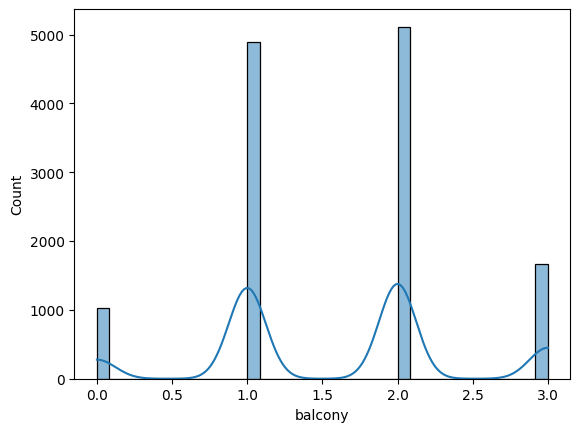

In [11]:
sns.histplot(df.balcony, kde=True)

#### 3.2.4 Filling and dropping

In [12]:
df = df.dropna(subset=['bath', 'location', 'size'])

#balcony column
df.balcony = df.balcony.fillna(0)

#function for filling with mods of respective groups
df['society'] = df.apply(
    lambda row: society_mode_map.get((row['area_type'], row['location']), 'Unknown') 
    if pd.isna(row['society']) else row['society'], 
    axis=1
)


In [13]:
df.shape

(13246, 8)

In [14]:
df.isna().sum()

area_type     0
location      0
size          0
society       0
total_sqft    0
bath          0
balcony       0
price         0
dtype: int64

✅ Cleaned

### 3.3 Fixing spelling mistakes for textual columns

In [15]:
#Following snippet is generated through ai

# 1. Standardize text format (lowercase, strip whitespace)
df['area_type'] = df['area_type'].str.strip()
df['location'] = df['location'].str.strip()
df['society'] = df['society'].str.strip()

# 2. Fix common patterns in area_type
df['area_type'] = df['area_type'].replace({
    'Super built-up  Area': 'Super Built-up Area',
    'Built-up  Area': 'Built-up Area',
    'Plot  Area': 'Plot Area',
    'Carpet  Area': 'Carpet Area'
})

# 3. For society column - since it has garbled text, replace short/corrupted entries
# with 'Unknown' if they're less than 5 characters or contain unusual patterns
df.loc[df['society'].str.len() < 5, 'society'] = 'Unknown'
df.loc[df['society'].str.contains(r'[^a-zA-Z\s]', regex=True, na=False), 'society'] = 'Unknown'

# 4. Capitalize properly for better readability
df['area_type'] = df['area_type'].str.title()
df['location'] = df['location'].str.title()

print("Spelling fixes applied!")
print(f"\nUpdated shape: {df.shape}")
print(f"\nArea types: {df['area_type'].unique()}")

Spelling fixes applied!

Updated shape: (13246, 8)

Area types: <StringArray>
['Super Built-Up Area', 'Plot Area', 'Built-Up Area', 'Carpet Area']
Length: 4, dtype: str


In [16]:
df[df['society']=='Unknown'].shape

(2799, 8)

## 4. Data Exploration

### 4.1 Area_type column

In [17]:
df.groupby('area_type')['area_type'].agg('count')

area_type
Built-Up Area          2410
Carpet Area              87
Plot Area              2009
Super Built-Up Area    8740
Name: area_type, dtype: int64

### 4.2 Size Column

In [18]:
df['size'].unique()

<StringArray>
[     '2 BHK',  '4 Bedroom',      '3 BHK',      '4 BHK',  '6 Bedroom',
  '3 Bedroom',      '1 BHK',       '1 RK',  '1 Bedroom',  '8 Bedroom',
  '2 Bedroom',  '7 Bedroom',      '5 BHK',      '7 BHK',      '6 BHK',
  '5 Bedroom',     '11 BHK',      '9 BHK',  '9 Bedroom',     '27 BHK',
 '10 Bedroom', '11 Bedroom',     '10 BHK',     '19 BHK',     '16 BHK',
 '43 Bedroom',     '14 BHK',      '8 BHK', '12 Bedroom',     '13 BHK',
 '18 Bedroom']
Length: 31, dtype: str

#### 4.3 BHK and Bedrooms

In [19]:
df['BHK'] = df['size'].apply(lambda x: int(x.split(' ')[0]))

In [20]:
df.BHK.unique()

array([ 2,  4,  3,  6,  1,  8,  7,  5, 11,  9, 27, 10, 19, 16, 43, 14, 12,
       13, 18])

In [21]:
df = df.drop(['size'], axis='columns')

### 4.3 Total sq_ft

In [22]:
df.total_sqft.unique()

<StringArray>
[       '1056',        '2600',        '1440',        '1521',        '1200',
        '1170',        '2732',        '3300',        '1310',        '1020',
 ...
        '1379',        '3124',        '9200',         '613',         '250',
        '2395',        '2758', '1133 - 1384',         '774',        '4689']
Length: 2067, dtype: str

In [23]:
#is the df uniform in types
df['total_sqft'].map(type).nunique() == 1

True

Wow, it has all same type of values

In [24]:
# what is the type?
df['total_sqft'].map(type)

0        <class 'str'>
1        <class 'str'>
2        <class 'str'>
3        <class 'str'>
4        <class 'str'>
             ...      
13315    <class 'str'>
13316    <class 'str'>
13317    <class 'str'>
13318    <class 'str'>
13319    <class 'str'>
Name: total_sqft, Length: 13246, dtype: object

Great 😒, now let's try to convert to float, if all of them do, it means they all were okay.

In [25]:
#function to return true if the string can be converted to a float
def is_float(x):
    try:
        float(x)
    except:
        return False
    return True

In [26]:
# lets see what are the values that are not simply numbers in string form
df[~df['total_sqft'].apply(is_float)]

,area_type,location,society,total_sqft,bath,balcony,price,BHK
30,Super Built-Up Area,Yelahanka,LedorSa,2100 - 2850,4.0,0.0,186.000,4
122,Super Built-Up Area,Hebbal,SNontle,3067 - 8156,4.0,0.0,477.000,4
137,Super Built-Up Area,8Th Phase Jp Nagar,Vaarech,1042 - 1105,2.0,0.0,54.005,2
165,Super Built-Up Area,Sarjapur,Kinuerg,1145 - 1340,2.0,0.0,43.490,2
188,Super Built-Up Area,Kr Puram,MCvarar,1015 - 1540,2.0,0.0,56.800,2
...,...,...,...,...,...,...,...,...
12975,Super Built-Up Area,Whitefield,Bhath N,850 - 1060,2.0,0.0,38.190,2
12990,Super Built-Up Area,Talaghattapura,Sodgere,1804 - 2273,3.0,0.0,122.000,3
13059,Super Built-Up Area,Harlur,Shodsir,1200 - 1470,2.0,0.0,72.760,2
13265,Super Built-Up Area,Hoodi,Ranuetz,1133 - 1384,2.0,0.0,59.135,2


In [27]:
#so there are ranges if not straight numbers, lets take avg of each of them
#lets write a function to convert ranges in to avgs
def sqft_to_num(x):
    tokens = x.split('-')
    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1])) / 2
    try:
        return float(x)
    except:
        return None
    

#testing the function
sqft_to_num('aflif')

In [28]:
df['total_sqft'] = df['total_sqft'].apply(sqft_to_num)

In [29]:
# let's see if there's still and anomaly remaining
df.total_sqft.isna().sum()

np.int64(46)

In [30]:
#dropping this much is fine i believe
df = df.dropna(subset=['total_sqft'])

## 5. Feature Engineering

In [31]:
df.head()

,area_type,location,society,total_sqft,bath,balcony,price,BHK
0,Super Built-Up Area,Electronic City Phase Ii,Coomee,1056.0,2.0,1.0,39.07,2
1,Plot Area,Chikka Tirupathi,Theanmp,2600.0,5.0,3.0,120.00,4
2,Built-Up Area,Uttarahalli,Gaent R,1440.0,2.0,3.0,62.00,3
3,Super Built-Up Area,Lingadheeranahalli,Soiewre,1521.0,3.0,1.0,95.00,3
4,Super Built-Up Area,Kothanur,Somumys,1200.0,2.0,1.0,51.00,2


### 5.1 Creating a new column, price per square feet

In [32]:
df['price_per_sqft'] = df['price'] * 100000 / df['total_sqft']

### 5.2 Exploring the location columns

In [33]:
df['location'].nunique()

1276

These are too much to encode. There'll certainly be rows who would have just one or two data points, lets remove them

In [34]:
#triming extra spaces
df.location = df.location.apply(lambda x : x.strip())

In [35]:
#lets look which locations have how many data points / rows
location_stats = df['location'].value_counts()
location_stats

location
Whitefield                                         533
Sarjapur  Road                                     392
Electronic City                                    304
Kanakpura Road                                     264
Thanisandra                                        235
                                                  ... 
Pattegarhpalya                                       1
Tilak Nagar                                          1
12Th Cross Srinivas Nagar Banshankari 3Rd Stage      1
Havanur Extension                                    1
Abshot Layout                                        1
Name: count, Length: 1276, dtype: int64

In [36]:
#lets decide the threshold to drop.
len(location_stats[location_stats<=10])

1036

So whatever location has less than 10 data points, I will call it as 'other'. Not dropping, because these are quite much.

In [37]:
other_locations = set(location_stats[location_stats<=10].index)
df.location = df.location.apply(lambda x : 'other' if x in other_locations else x)

In [38]:
df.location.nunique()

241

Good enough

## 6. Outlier Removal

We also need domain-specific knowledge here, ChatGPT will help.

### 6.1 Unrealistic Room Size

In [39]:
df = df[~(df.total_sqft / df.BHK < 250)]
df.shape

(12588, 9)

### 6.2 Price Per Sq ft

In [40]:
df.price_per_sqft.describe()

count     12588.000000
mean       6352.843657
std        4209.946717
min         267.829813
25%        4216.696674
50%        5302.169502
75%        6969.337210
max      176470.588235
Name: price_per_sqft, dtype: float64

Ok, so we will use the std method to remove the outliers from here. I will remove all the datapoints that are beyond 2 stds from the mean. 
*Remember to do it area-wise because prices change with area.*

In [41]:
# a function that removes all data points from the df which have price per sqft less than mean+2std or mean-2std of the
# respective location
def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)
        reduced_df = subdf[(subdf.price_per_sqft > (m-2*st)) & (subdf.price_per_sqft <= (m+2*st))]
        df_out = pd.concat([df_out, reduced_df], ignore_index=True)
    return df_out


In [42]:
df = remove_pps_outliers(df)
df.shape

(12054, 9)

### 6.3 Price Normalization wrt BHK

Price of 1BHK should be less than 2BHK's in a respective area and so on for others.

#### 6.4 Visualization of outliers

In [43]:
# lets see the scatter chart for 2 BHK and 3 BHK in Rajaji Nagar
# the following function is for generating scatter charts for 2 BHK and 3 BHK in a given location

def plot_scatter_chart(df, location):
    bhk_df = df[(df.location == location) & (df.BHK == 2)]
    bhk_plus_one_df = df[(df.location == location) & (df.BHK == 3)]
    
    plt.figure(figsize=(10, 6))
    plt.scatter(bhk_df.total_sqft, bhk_df.price, color='blue', label=f'2 BHK', alpha=0.6)
    plt.scatter(bhk_plus_one_df.total_sqft, bhk_plus_one_df.price, color='red', label=f'3 BHK', alpha=0.6, marker='^')
    
    plt.xlabel('Total Square Feet')
    plt.ylabel('Price (in Lakhs)')
    plt.title(f'Price vs Total Sqft for 2 BHK and 3 BHK in {location}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

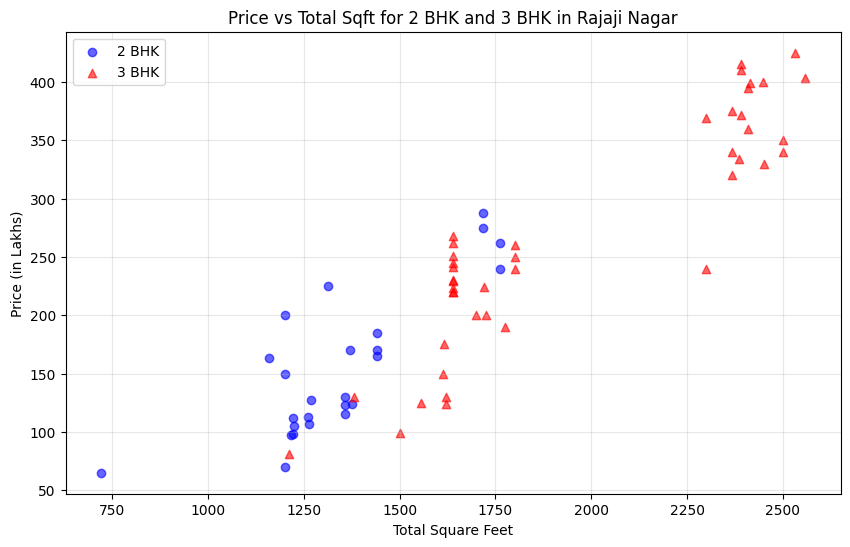

In [44]:
plot_scatter_chart(df, 'Rajaji Nagar')

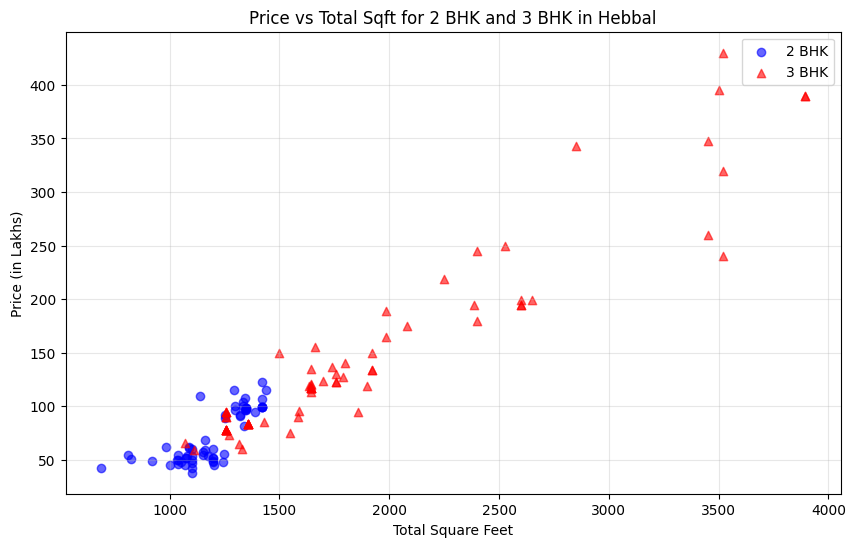

In [45]:
# let's also check for some other location
plot_scatter_chart(df, 'Hebbal')

There are some data points where in a specific area, 2bhk home is more priced than 3 bhk homes

In [46]:
#the following function will remove all the data points if 3bhk home is priced less 2bhk's mean, 2bhk is priced less than 
#1 bhk's mean and so on for all bhk values in all locations

def remove_bhk_price_outliers(df):
    exclude_indices = np.array([])
    for location, location_df in df.groupby('location'):
        bhk_stats = {}
        for bhk, bhk_df in location_df.groupby('BHK'):
            bhk_stats[bhk] = {
                'mean' : np.mean(bhk_df.price_per_sqft),
                'std' : np.std(bhk_df.price_per_sqft),
                'count' : bhk_df.shape[0]
            }
        for bhk, bhk_df in location_df.groupby('BHK'):
            #compare every bhk in current to its previous bhk's mean and drop
            prev_bhk = bhk_stats.get(bhk-1)
            if prev_bhk and prev_bhk['count']>5:
                exclude_indices = np.append(exclude_indices, bhk_df[bhk_df.price_per_sqft<(prev_bhk['mean'])].index.values)
    return df.drop(index=exclude_indices, axis='index')

In [47]:
df = remove_bhk_price_outliers(df)

In [48]:
df.shape

(8468, 9)

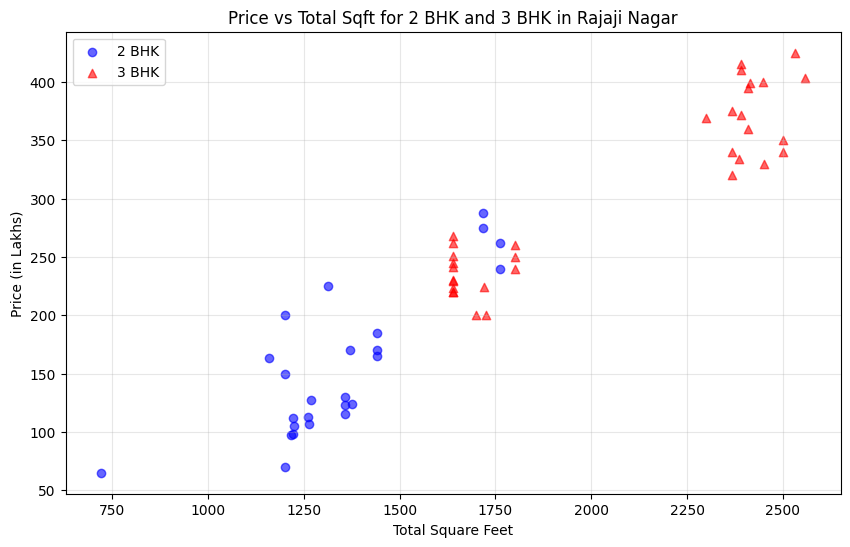

In [49]:
#plotting again to see the improvements
plot_scatter_chart(df, 'Rajaji Nagar')

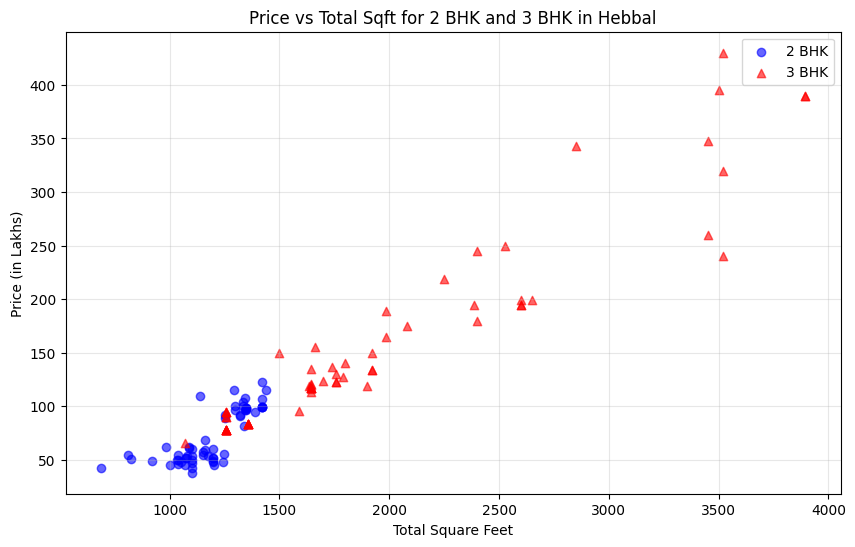

In [50]:
plot_scatter_chart(df, 'Hebbal')

Text(0, 0.5, 'count')

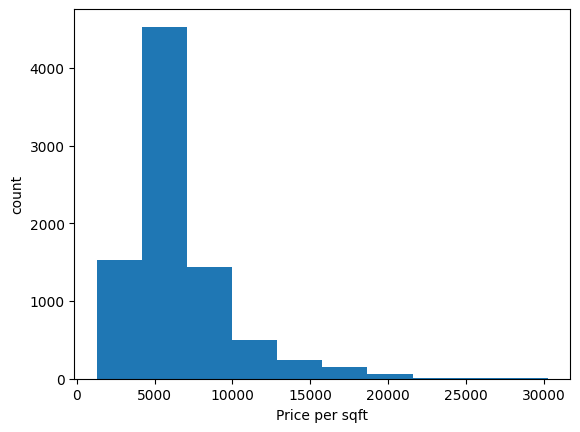

In [51]:
#checking now the distribution of the price_per_sqft
plt.hist(df.price_per_sqft) 
plt.xlabel('Price per sqft')
plt.ylabel('count')

### 6.5 Bath column

In [52]:
df.bath.unique()

array([ 4.,  3.,  2.,  5.,  7.,  1.,  8.,  6.,  9., 10., 12., 14., 27.,
       16., 13.])

27 bathrooms huh? Looks like a whole village.

In [53]:
df[df.bath>10]

,area_type,location,society,total_sqft,bath,balcony,price,BHK,price_per_sqft
6322,Super Built-Up Area,Neeladri Nagar,GeereEc,4000.0,12.0,0.0,160.0,10,4000.000000
9745,Plot Area,other,Srvasks,3300.0,14.0,0.0,500.0,9,15151.515152
9870,Super Built-Up Area,other,Unknown,8000.0,27.0,0.0,230.0,27,2875.000000
10218,Super Built-Up Area,other,Unknown,10000.0,16.0,0.0,550.0,16,5500.000000
11030,Super Built-Up Area,other,Unknown,6000.0,12.0,0.0,150.0,11,2500.000000
11392,Super Built-Up Area,other,Unknown,5425.0,13.0,0.0,275.0,13,5069.124424


Text(0, 0.5, 'frequency in dataset')

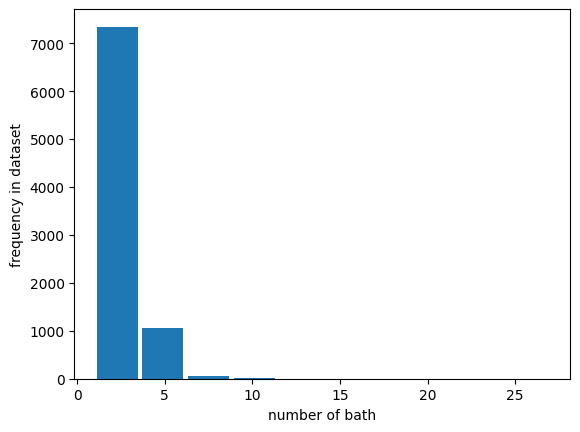

In [54]:
plt.hist(df.bath, rwidth = 0.9)
plt.xlabel('number of bath')
plt.ylabel('frequency in dataset')

In [55]:
#lets remove all the rows where bath is greater than 2+bhk, this is mostly confirmed by 
#discussing with the specialists/AI

df = df[~(df.bath > df.BHK+2)]
df.shape

(8463, 9)

Now when the dataset is neat and clean, let's drop the columns not needed to train or the ones we only used for outlier detection.

In [56]:
df.columns

Index(['area_type', 'location', 'society', 'total_sqft', 'bath', 'balcony',
       'price', 'BHK', 'price_per_sqft'],
      dtype='str')

In [57]:
df = df.drop(['price_per_sqft'], axis='columns')

In [58]:
df.shape

(8463, 8)

## 7. Encoding

In [59]:
#because we are not using the pipelines, we are good to use pd.get_dummies for
#one hot encoding the location column

location_dummies = pd.get_dummies(df.location)
society_dummies = pd.get_dummies(df.society)
area_type_dummies = pd.get_dummies(df.area_type, drop_first=True)

location_dummies = location_dummies.drop(['other'], axis='columns')
society_dummies = society_dummies.drop(['Unknown'], axis='columns')

dummies = pd.concat([location_dummies, society_dummies, area_type_dummies], axis='columns')
dummies.shape

(8463, 2136)

In [60]:
#merging with original df
df = pd.concat([df, dummies], axis='columns')
df = df.drop(['society','location','area_type'], axis='columns')
df.shape

(8463, 2141)

## 8. Training the model

In [61]:
x = df.drop(['price'], axis='columns')
y = df.price

In [62]:
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8)

### 8.1 Selecting the best model

Following columns are commented out as I do not want to execute them again, the final model is selected by running them the first time.

In [63]:
# models = {
#     'LinearRegression': {
#         'model': LinearRegression(),
#         'params': {}
#     },
    
#     'Ridge': {
#         'model': Ridge(),
#         'params': {
#             'alpha': [0.1, 1, 10, 100]
#         }
#     },
    
#     'Lasso': {
#         'model': Lasso(),
#         'params': {
#             'alpha': [0.01, 0.1, 1, 10]
#         }
#     },
    
#     'DecisionTree': {
#         'model': DecisionTreeRegressor(random_state=42),
#         'params': {
#             'max_depth': [10, 20, None],
#             'min_samples_split': [2, 5, 10]
#         }
#     },
    
#     'RandomForest': {
#         'model': RandomForestRegressor(random_state=42),
#         'params': {
#             'n_estimators': [100, 200],
#             'max_depth': [10, 20, None],
#             'min_samples_split': [2, 5]
#         }
#     },
    
#     'GradientBoosting': {
#         'model': GradientBoostingRegressor(random_state=42),
#         'params': {
#             'n_estimators': [100, 200],
#             'learning_rate': [0.01, 0.1],
#             'max_depth': [3, 5]
#         }
#     }
# }

In [64]:
# Grid Search CV tries every combination for all parameters for ONE MODEL. For more than one models, we still 
# need a for loop

# scores = []
# cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

# for model_name, model_dict in models.items():
#     grid_search_obj = GridSearchCV(model_dict['model'], model_dict['params'], cv=cv, return_train_score=False)
#     grid_search_obj.fit(x,y)
#     scores.append({
#         'model' : model_name,
#         'best parameters' : grid_search_obj.best_params_,
#         'best score' : grid_search_obj.best_score_
#     })

In [65]:
# scores = pd.DataFrame(scores, columns=['model', 'best parameters', 'best score'])
# scores

Our winner model is Gradient Boosting.

In [66]:
# params_GradientBoosting = scores[scores['model']=='GradientBoosting']['best parameters'].values[0]
# params_GradientBoosting

In [67]:
model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3)
model.fit(x_train,y_train)
model.score(x_test, y_test)

0.7985590351089351

### 8.2 Manual Prediction Testing

In [68]:
def predict_price(location, society, area_type, total_sqft, bath, balcony, bhk):
    
    input_df = pd.DataFrame(columns=x.columns)
    input_df.loc[0] = 0
    
    input_df.loc[0, 'total_sqft'] = total_sqft
    input_df.loc[0, 'bath'] = bath
    input_df.loc[0, 'balcony'] = balcony
    input_df.loc[0, 'BHK'] = bhk
    
    # Set location (one-hot encoded)
    if location in input_df.columns:
        input_df.loc[0, location] = 1
    elif 'other' in input_df.columns:
        input_df.loc[0, 'other'] = 1
    
    # Set society (one-hot encoded)
    if society in input_df.columns:
        input_df.loc[0, society] = 1
    
    # Set area_type (one-hot encoded with drop_first=True)
    # The dropped category was the first alphabetically
    area_type_cols = ['Carpet Area', 'Plot Area', 'Super Built-Up Area']
    for col in area_type_cols:
        if col in input_df.columns and col == area_type:
            input_df.loc[0, col] = 1
    
    # Make prediction
    prediction = model.predict(input_df)[0]
    
    return round(prediction, 2)

Predicting the following rows:

| area_type | availability | location | size | society | total_sqft | bath | balcony | price |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| Super built-up Area | 19-Dec | Electronic City Phase II | 2 BHK | Coomee | 1056 | 2 | 1 | 39.07 |
| Plot Area | Ready To Move | Chikka Tirupathi | 4 Bedroom | Theanmp | 2600 | 5 | 3 | 120 |
| Built-up Area | Ready To Move | Uttarahalli | 3 BHK | | 1440 | 2 | 3 | 62 |
| Super built-up Area | Ready To Move | Lingadheeranahalli | 3 BHK | Soiewre | 1521 | 3 | 1 | 95 |
| Super built-up Area | Ready To Move | Kothanur | 2 BHK | | 1200 | 2 | 1 | 51 |

In [69]:

price1 = predict_price('Electronic City Phase Ii', 'Coomee', 'Super Built-Up Area', 1056, 2, 1, 2)
print(f"Prediction 1 (Actual: 39.07): {price1} lakhs")

price2 = predict_price('Chikka Tirupathi', 'Theanmp', 'Plot Area', 2600, 5, 3, 4)
print(f"Prediction 2 (Actual: 120): {price2} lakhs")

price3 = predict_price('Uttarahalli', 'Unknown', 'Built-Up Area', 1440, 2, 3, 3)
print(f"Prediction 3 (Actual: 62): {price3} lakhs")

price4 = predict_price('Lingadheeranahalli', 'Soiewre', 'Super Built-Up Area', 1521, 3, 1, 3)
print(f"Prediction 4 (Actual: 95): {price4} lakhs")

price5 = predict_price('Kothanur', 'Unknown', 'Super Built-Up Area', 1200, 2, 1, 2)
print(f"Prediction 5 (Actual: 51): {price5} lakhs")

Prediction 1 (Actual: 39.07): 48.03 lakhs
Prediction 2 (Actual: 120): 184.04 lakhs
Prediction 3 (Actual: 62): 79.39 lakhs
Prediction 4 (Actual: 95): 99.69 lakhs
Prediction 5 (Actual: 51): 66.48 lakhs


Just fine.

## 9. Exporting

In [70]:
with open('banglore_home_price_prediction_model.pkl', 'wb') as f:
    pickle.dump(model, f)

We also need to export the column information to predict correctly.

In [71]:
columns = {
    'other_columns' : [c for c in x.columns \
                        if c not in location_dummies and \
                        c not in society_dummies and \
                        c not in area_type_dummies],
    'location_columns' : [c.lower() for c in location_dummies],
    'society_columns' : [c.lower() for c in society_dummies],
    'area_type_columns' : [c.lower() for c in area_type_dummies]
}
with open('columns.json', 'w') as f:
    f.write(json.dumps(columns))